# Kirkaldy LG M50T — Comprehensive Degradation Analysis
**Expt 5 — Standard Cycle Aging (Control)**

This notebook generates 12 publication-quality figures covering SOH fade, degradation modes (DMA), electrode capacity, resistance, coulombic efficiency, temperature, voltage curves, ICA, DVA, voltage at fixed SOC, and a summary dashboard.

> **Edit `DATA_ROOT` in Cell 2 to point to your local data folder.**

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d

warnings.filterwarnings('ignore')

# ── Inline display for Jupyter ──────────────────────────────────────────
%matplotlib inline
matplotlib.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    12,
    'legend.fontsize':   10,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
})

print('Libraries loaded successfully ✓')

Libraries loaded successfully ✓


## ⚙️ Configuration — Edit `DATA_ROOT` here

In [2]:
# ── EDIT THIS PATH to match your data folder ─────────────────────────
DATA_ROOT = r'D:\Mtech\Battery (MTP)\Stage 2\Data\IMP_1\Expt 5 - Standard Cycle Aging (Control)\exp_output_1'

CELL_CONFIG = {
    'A': {'temp': 10,  'color': '#1f77b4', 'marker': 'o'},
    'B': {'temp': 10,  'color': '#17becf', 'marker': 's'},
    'C': {'temp': 10,  'color': '#aec7e8', 'marker': '^'},
    'D': {'temp': 25,  'color': '#2ca02c', 'marker': 'o'},
    'E': {'temp': 25,  'color': '#98df8a', 'marker': 's'},
    'F': {'temp': 40,  'color': '#d62728', 'marker': 'o'},
    'G': {'temp': 40,  'color': '#ff9896', 'marker': 's'},
    'H': {'temp': 40,  'color': '#ffbb78', 'marker': '^'},
}

TEMP_COLORS  = {10: '#1f77b4', 25: '#2ca02c', 40: '#d62728'}
BOL_CAPACITY = 4878.88   # mAh  (Beginning-of-Life capacity)

print(f'DATA_ROOT set to: {DATA_ROOT}')
print(f'Folder exists: {os.path.isdir(DATA_ROOT)}')

DATA_ROOT set to: D:\Mtech\Battery (MTP)\Stage 2\Data\IMP_1\Expt 5 - Standard Cycle Aging (Control)\exp_output_1
Folder exists: True


## 📂 Path Helpers & Data Loaders

In [3]:
# ── Path helpers ─────────────────────────────────────────────────────
def summary_path(cell):
    t = CELL_CONFIG[cell]['temp']
    return os.path.join(DATA_ROOT, 'Summary Data_Exp', 'Performance Summary_Exp',
                        f'Expt 5 - cell {cell} ({t}degC) - Processed Data.csv')

def cycle_path(cell):
    return os.path.join(DATA_ROOT, 'Summary Data_Exp', 'Ageing Sets Summary_Exp',
                        'Summary per Cycle_Exp', f'expt 5 - cell {cell} - cycle_data.csv')

def discharge_01C_path(cell, rpt):
    return os.path.join(DATA_ROOT, 'RPT_Discharge_Exp', f'Cell {cell} exp',
                        f'Expt 5 - cell {cell} - RPT{rpt} - 0.1C discharge data.csv')

# ── Data loaders ──────────────────────────────────────────────────────
def load_summary(cell):
    p = summary_path(cell)
    if not os.path.exists(p):
        return None
    df = pd.read_csv(p)
    df['cell'] = cell
    df['temp'] = CELL_CONFIG[cell]['temp']
    r = '0.1s Resistance [Ohms]'
    if r in df.columns:
        med = df[r].dropna().median()
        df.loc[df[r] > med * 3, r] = np.nan
        df[r] = df[r].interpolate('linear')
    return df

def load_cycle(cell):
    p = cycle_path(cell)
    if not os.path.exists(p):
        return None
    df = pd.read_csv(p)
    df['cell'] = cell
    df['temp'] = CELL_CONFIG[cell]['temp']
    df = df[df['Cycle'] > 0].copy()
    df['SOH_approx'] = df['Discharge Capacity [A h]'] / (BOL_CAPACITY / 1000)
    df['delta_T'] = (df['Max. Discharge Temperature [°C]']
                     - df['Min. Discharge Temperature [°C]'])
    return df

def load_discharge(cell, rpt):
    p = discharge_01C_path(cell, rpt)
    if not os.path.exists(p):
        return None
    df = pd.read_csv(p)
    df = df[df['Current (mA)'] < -100].copy()
    return df.sort_values('Charge (mA.h)').reset_index(drop=True)

# ── Signal processing helpers ──────────────────────────────────────────

def ica(df, n=2000, w=151, poly=3):
    if df is None or len(df) < 200:
        return None, None
    V = df['Voltage (V)'].values
    Q = df['Charge (mA.h)'].values
    idx = np.argsort(V)[::-1]
    V, Q = V[idx], Q[idx]
    Vu = np.linspace(V.min(), V.max(), n)
    try:
        Qu = interp1d(V, Q, kind='cubic', bounds_error=False,
                      fill_value='extrapolate')(Vu)
    except Exception:
        return None, None
    dQdV = np.gradient(Qu, Vu)
    if len(dQdV) > w:
        dQdV = savgol_filter(dQdV, w, poly)
    return Vu, dQdV
    
def dva(df, n=2000, w=151, poly=3):
    if df is None or len(df) < 200:
        return None, None
    Q = df['Charge (mA.h)'].values
    V = df['Voltage (V)'].values
    idx = np.argsort(Q)
    Q, V = Q[idx], V[idx]
    Qu = np.linspace(Q.min(), Q.max(), n)
    try:
        Vu = interp1d(Q, V, kind='cubic', bounds_error=False,
                      fill_value='extrapolate')(Qu)
    except Exception:
        return None, None

    if len(Vu) > w:
        Vu = savgol_filter(Vu, w, poly)        # smooth V first
    dVdQ = np.gradient(Vu, Qu)
    if len(dVdQ) > w:
        dVdQ = savgol_filter(dVdQ, w, poly)    # smooth the derivative too
    return Qu, dVdQ                             # absolute mAh

'''
def dva(df, n=2000, w=151, poly=3):
    if df is None or len(df) < 200:
        return None, None
    Q = df['Charge (mA.h)'].values
    V = df['Voltage (V)'].values
    idx = np.argsort(Q)
    Q, V = Q[idx], V[idx]
    Qu = np.linspace(Q.min(), Q.max(), n)
    try:
        Vu = interp1d(Q, V, kind='cubic', bounds_error=False,
                      fill_value='extrapolate')(Qu)
    except Exception:
        return None, None
    dVdQ = np.gradient(Vu, Qu)
    if len(dVdQ) > w:
        dVdQ = savgol_filter(dVdQ, w, poly)
    return Qu / Qu.max(), dVdQ
'''
def v_at_soc(df, socs=[0.2, 0.5, 0.8]):
    if df is None or len(df) == 0:
        return {}
    Qmax = df['Charge (mA.h)'].max()
    out = {}
    for s in socs:
        i = (df['Charge (mA.h)'] - Qmax * s).abs().idxmin()
        out[s] = df.loc[i, 'Voltage (V)']
    return out

def rpt_colors(n=16):
    return plt.cm.plasma(np.linspace(0.1, 0.9, n))

print('Path helpers and loaders defined ✓')

Path helpers and loaders defined ✓


## 📥 Load All Cell Data

In [4]:
summaries, cycles = {}, {}
for c in CELL_CONFIG:
    s = load_summary(c)
    cyc = load_cycle(c)
    if s is not None:
        summaries[c] = s
        print(f'  ✓ Summary Cell {c}  ({len(s)} RPTs)')
    else:
        print(f'  ✗ Summary Cell {c}  not found  →  {summary_path(c)}')
    if cyc is not None:
        cycles[c] = cyc
        print(f'  ✓ Cycles  Cell {c}  ({len(cyc)} cycles)')
    else:
        print(f'  ✗ Cycles  Cell {c}  not found')

if not summaries:
    raise RuntimeError('\n❌ No summary data found. Please check DATA_ROOT above.')

# Shorthand lambdas
cl = lambda c: CELL_CONFIG[c]['color']
mk = lambda c: CELL_CONFIG[c]['marker']
lb = lambda c: f"Cell {c} ({CELL_CONFIG[c]['temp']}°C)"

print(f'\nLoaded {len(summaries)} summary files and {len(cycles)} cycle files.')

  ✓ Summary Cell A  (16 RPTs)
  ✓ Cycles  Cell A  (1160 cycles)
  ✓ Summary Cell B  (16 RPTs)
  ✓ Cycles  Cell B  (1184 cycles)
  ✓ Summary Cell C  (16 RPTs)
  ✓ Cycles  Cell C  (1169 cycles)
  ✓ Summary Cell D  (16 RPTs)
  ✓ Cycles  Cell D  (1169 cycles)
  ✓ Summary Cell E  (16 RPTs)
  ✓ Cycles  Cell E  (1170 cycles)
  ✓ Summary Cell F  (16 RPTs)
  ✓ Cycles  Cell F  (1170 cycles)
  ✓ Summary Cell G  (16 RPTs)
  ✓ Cycles  Cell G  (1169 cycles)
  ✓ Summary Cell H  (16 RPTs)
  ✓ Cycles  Cell H  (1170 cycles)

Loaded 8 summary files and 8 cycle files.


## Figure 1 — State of Health Fade (All Cells)

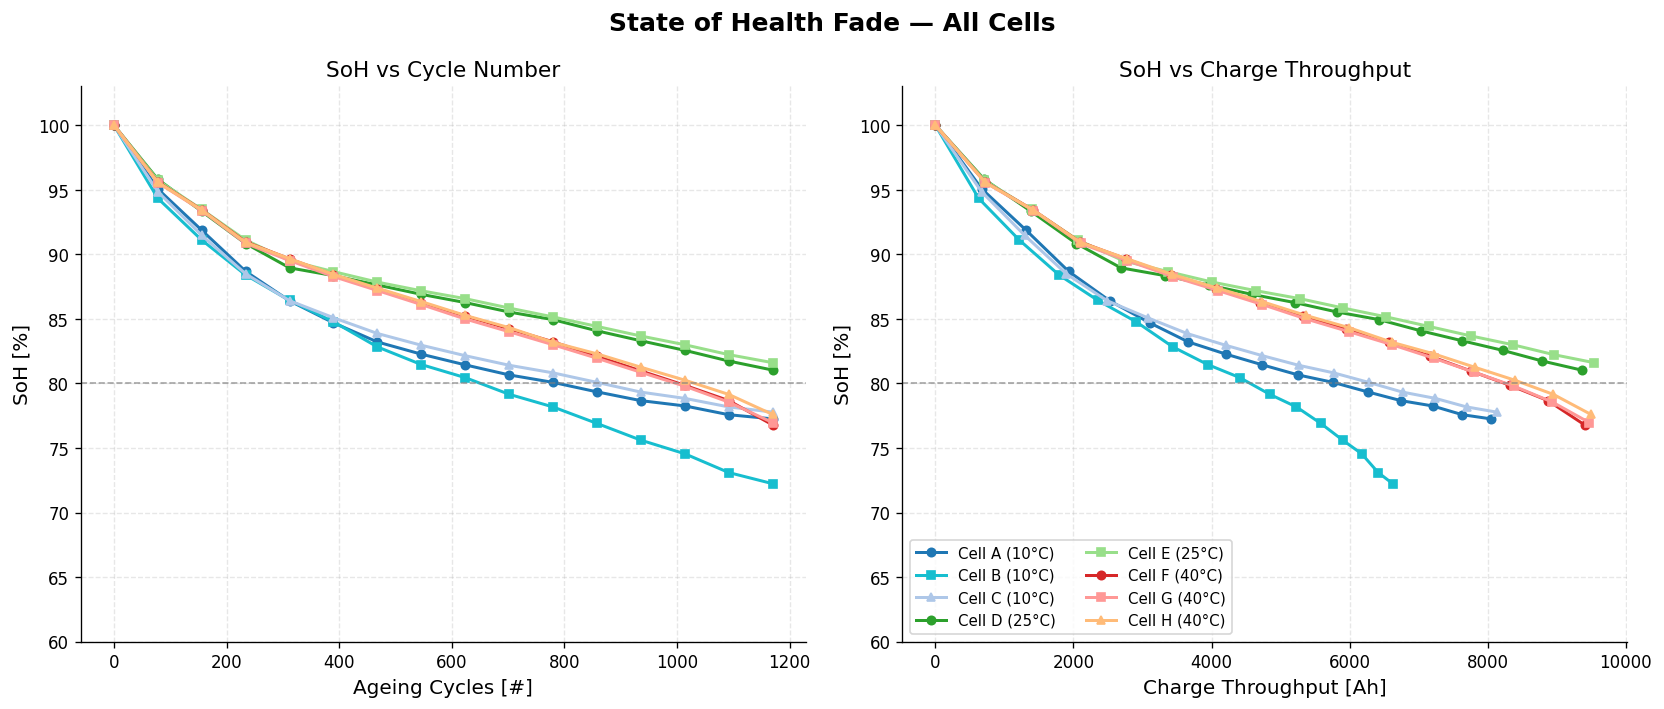

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('State of Health Fade — All Cells', fontsize=15, fontweight='bold')

for c, df in summaries.items():
    kw = dict(color=cl(c), marker=mk(c), markersize=5, linewidth=1.8)
    ax1.plot(df['Ageing Cycles'],           df['SoH']*100, **kw, label=lb(c))
    ax2.plot(df['Charge Throughput [A h]'], df['SoH']*100, **kw, label=lb(c))

for ax, xl in zip([ax1, ax2], ['Ageing Cycles [#]', 'Charge Throughput [Ah]']):
    ax.axhline(80, color='gray', ls='--', lw=1, alpha=0.7)
    ax.set_xlabel(xl); ax.set_ylabel('SoH [%]'); ax.set_ylim(60, 103)

ax1.set_title('SoH vs Cycle Number')
ax2.set_title('SoH vs Charge Throughput')
ax2.legend(ncol=2, fontsize=9, loc='lower left')
fig.tight_layout()
plt.savefig('Fig01_SOH_Fade.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Figure 2 — Degradation Modes (DMA)

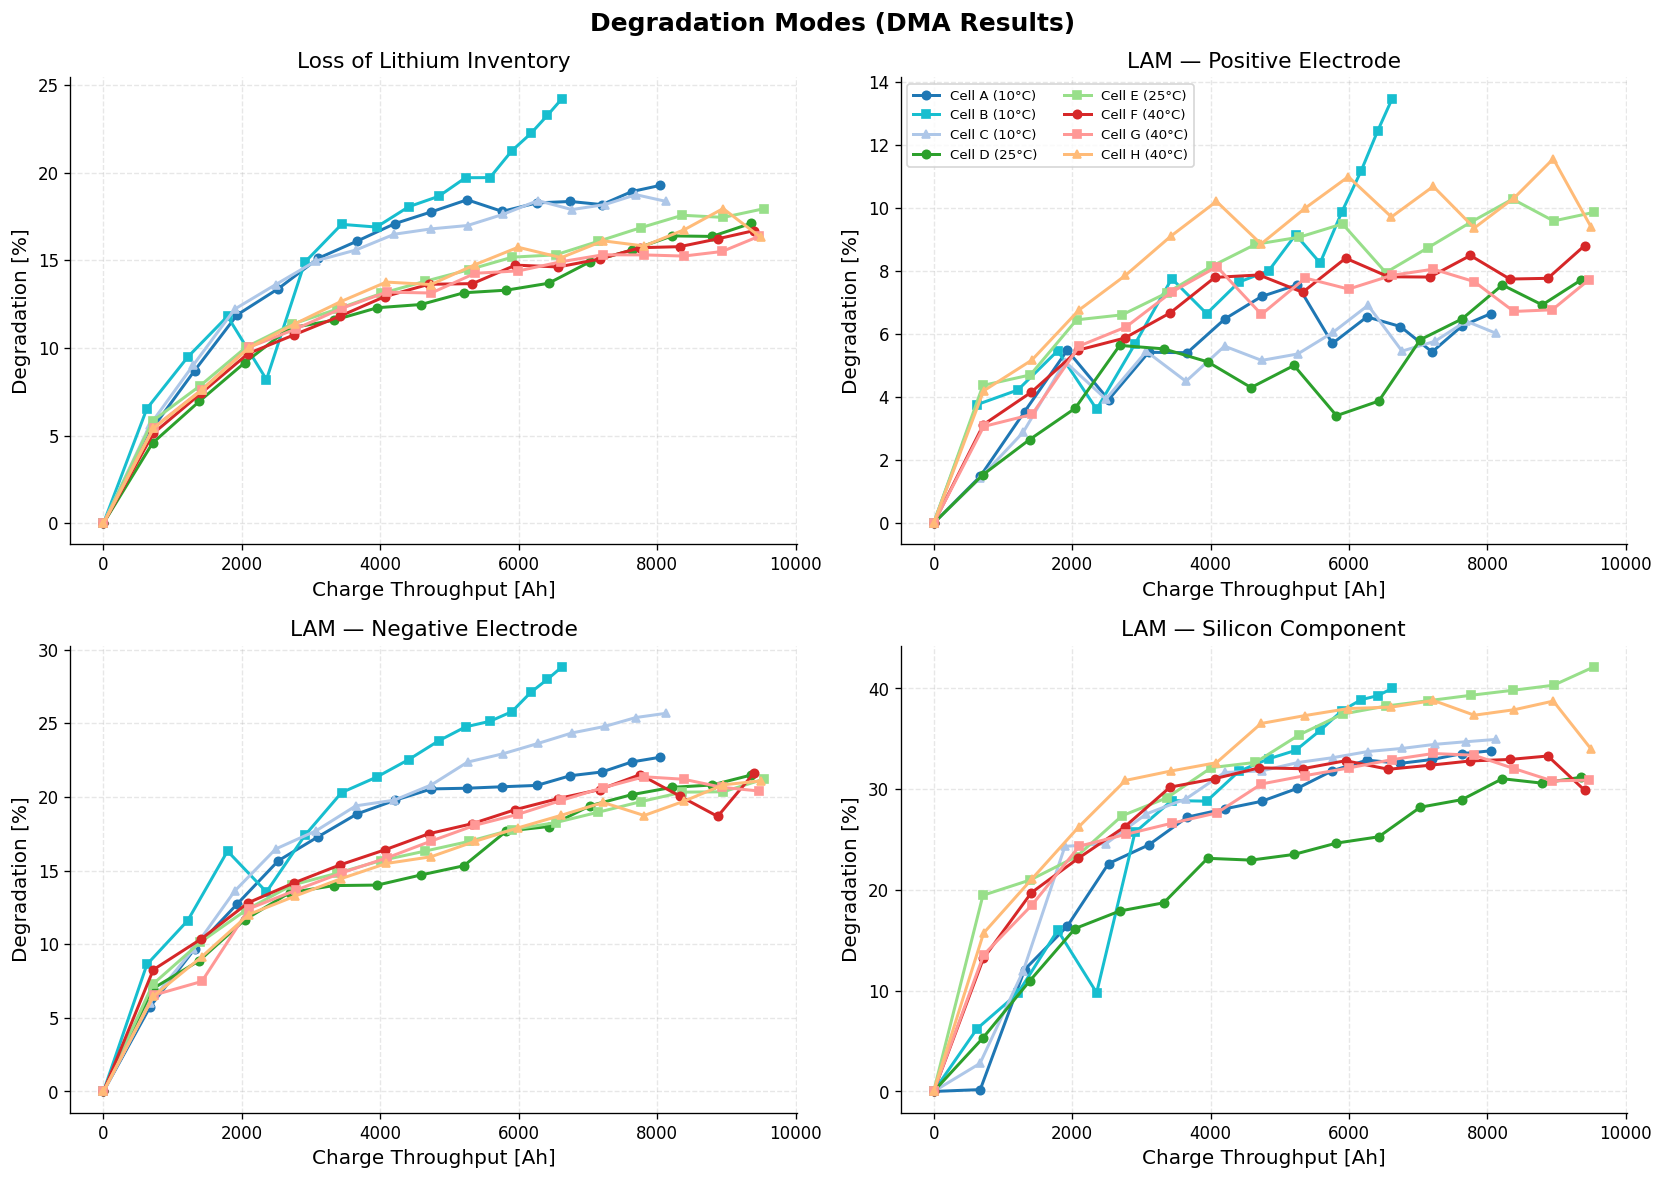

In [6]:
modes = [('LLI',         'Loss of Lithium Inventory'),
         ('LAM PE',      'LAM — Positive Electrode'),
         ('LAM NE_tot',  'LAM — Negative Electrode'),
         ('LAM NE_Si',   'LAM — Silicon Component')]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Degradation Modes (DMA Results)', fontsize=15, fontweight='bold')

for ax, (col, title) in zip(axes.flatten(), modes):
    for c, df in summaries.items():
        if col not in df.columns: continue
        ax.plot(df['Charge Throughput [A h]'], df[col]*100,
                color=cl(c), marker=mk(c), markersize=5, lw=1.8, label=lb(c))
    ax.set_title(title)
    ax.set_xlabel('Charge Throughput [Ah]')
    ax.set_ylabel('Degradation [%]')

axes[0][1].legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.savefig('Fig02_Degradation_Modes.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Figure 3 — Electrode-Level Capacity Evolution

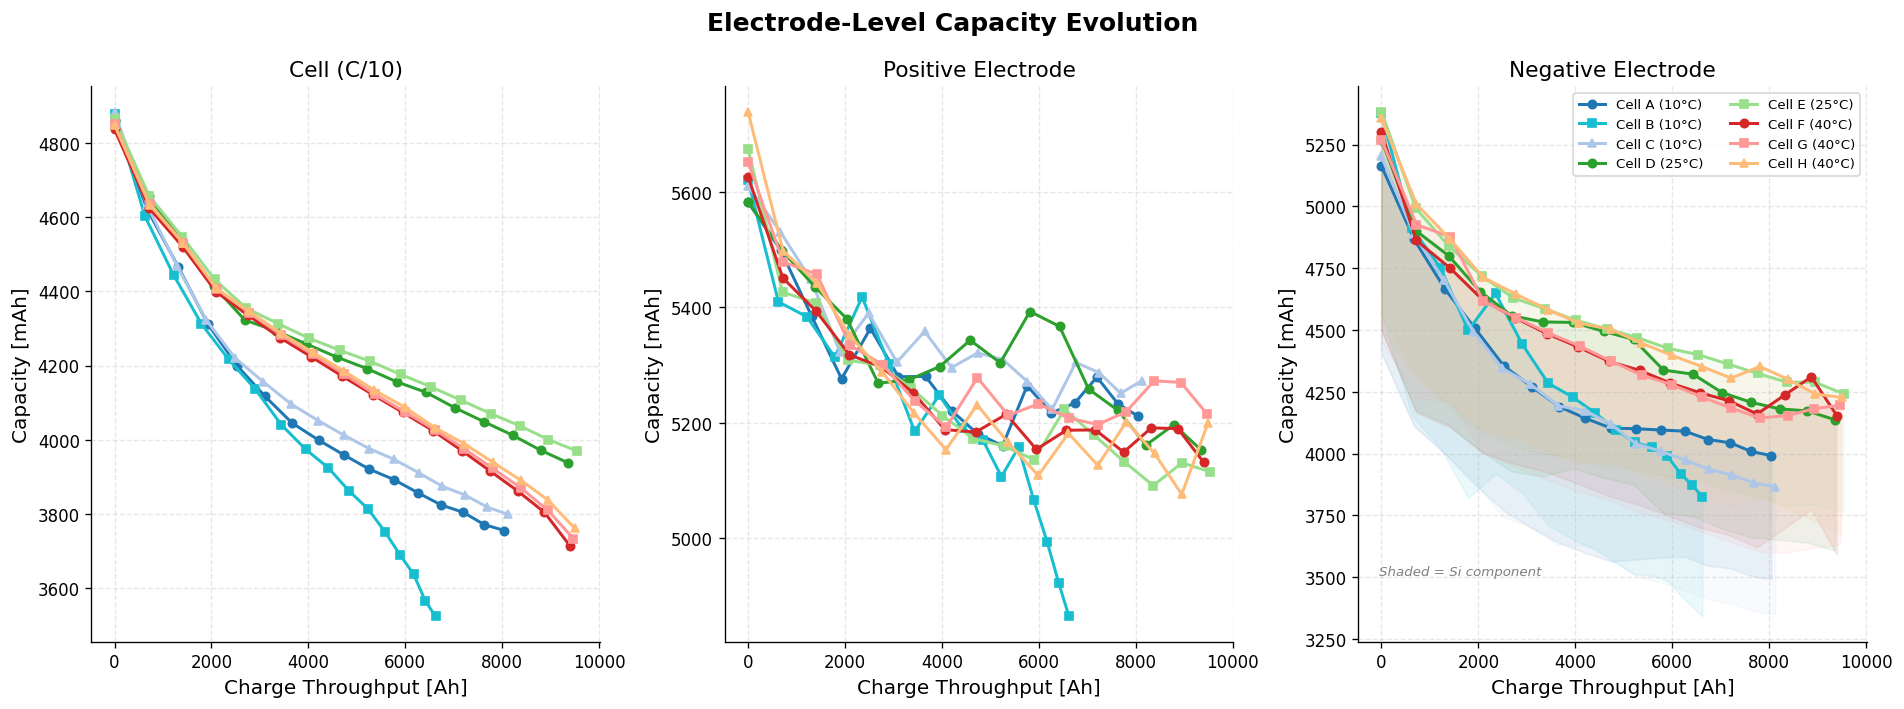

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Electrode-Level Capacity Evolution', fontsize=15, fontweight='bold')

for ax, (col, title) in zip(axes,
    [('C/10 Capacity [mA h]', 'Cell (C/10)'),
     ('PE Capacity [mA h]',   'Positive Electrode'),
     ('NE Capacity [mA h]',   'Negative Electrode')]):
    for c, df in summaries.items():
        if col not in df.columns: continue
        ax.plot(df['Charge Throughput [A h]'], df[col],
                color=cl(c), marker=mk(c), markersize=5, lw=1.8, label=lb(c))
    ax.set_title(title)
    ax.set_xlabel('Charge Throughput [Ah]')
    ax.set_ylabel('Capacity [mAh]')

# Shade Si component on NE panel
for c, df in summaries.items():
    if 'NE_Gr Capacity [mA h]' in df.columns and 'NE Capacity [mA h]' in df.columns:
        axes[2].fill_between(df['Charge Throughput [A h]'],
                              df['NE_Gr Capacity [mA h]'],
                              df['NE Capacity [mA h]'],
                              alpha=0.08, color=cl(c))

axes[2].text(0.04, 0.12, 'Shaded = Si component', transform=axes[2].transAxes,
              fontsize=8, style='italic', color='gray')
axes[2].legend(ncol=2, fontsize=8, loc='upper right')
fig.tight_layout()
plt.savefig('Fig03_Electrode_Capacity.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Figure 4 — Internal Resistance Evolution

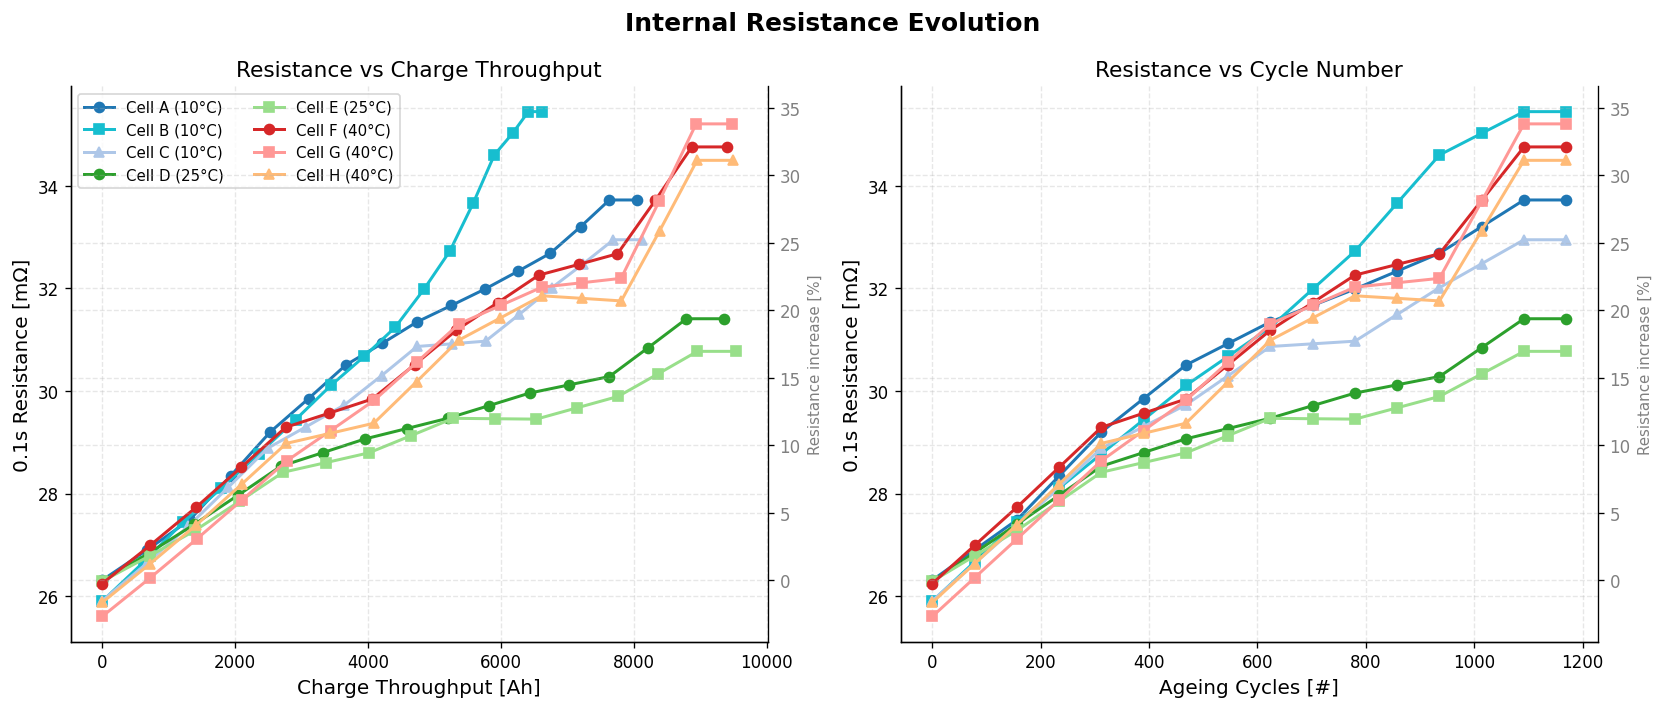

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Internal Resistance Evolution', fontsize=15, fontweight='bold')

r0_bol = None
for c, df in summaries.items():
    rc = '0.1s Resistance [Ohms]'
    if rc not in df.columns: continue
    ddr = df.dropna(subset=[rc])
    if ddr.empty: continue
    r_mO = ddr[rc].values * 1000
    if r0_bol is None: r0_bol = r_mO[0]
    kw = dict(color=cl(c), marker=mk(c), markersize=6, lw=1.8)
    ax1.plot(ddr['Charge Throughput [A h]'], r_mO, **kw, label=lb(c))
    ax2.plot(ddr['Ageing Cycles'],           r_mO, **kw)

for ax, xl in zip([ax1, ax2], ['Charge Throughput [Ah]', 'Ageing Cycles [#]']):
    ax.set_xlabel(xl); ax.set_ylabel('0.1s Resistance [mΩ]')

ax1.set_title('Resistance vs Charge Throughput')
ax2.set_title('Resistance vs Cycle Number')
ax1.legend(ncol=2, fontsize=9)

if r0_bol:
    for ax in [ax1, ax2]:
        ax2b = ax.twinx()
        ax2b.set_ylabel('Resistance increase [%]', color='gray', fontsize=9)
        ax2b.tick_params(axis='y', labelcolor='gray')
        lo, hi = ax.get_ylim()
        ax2b.set_ylim([(v - r0_bol)/r0_bol*100 for v in (lo, hi)])
        ax.spines['right'].set_visible(True)

fig.tight_layout()
plt.savefig('Fig04_Resistance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Figure 5 — Per-Cycle Capacity Fade (Dense Data)

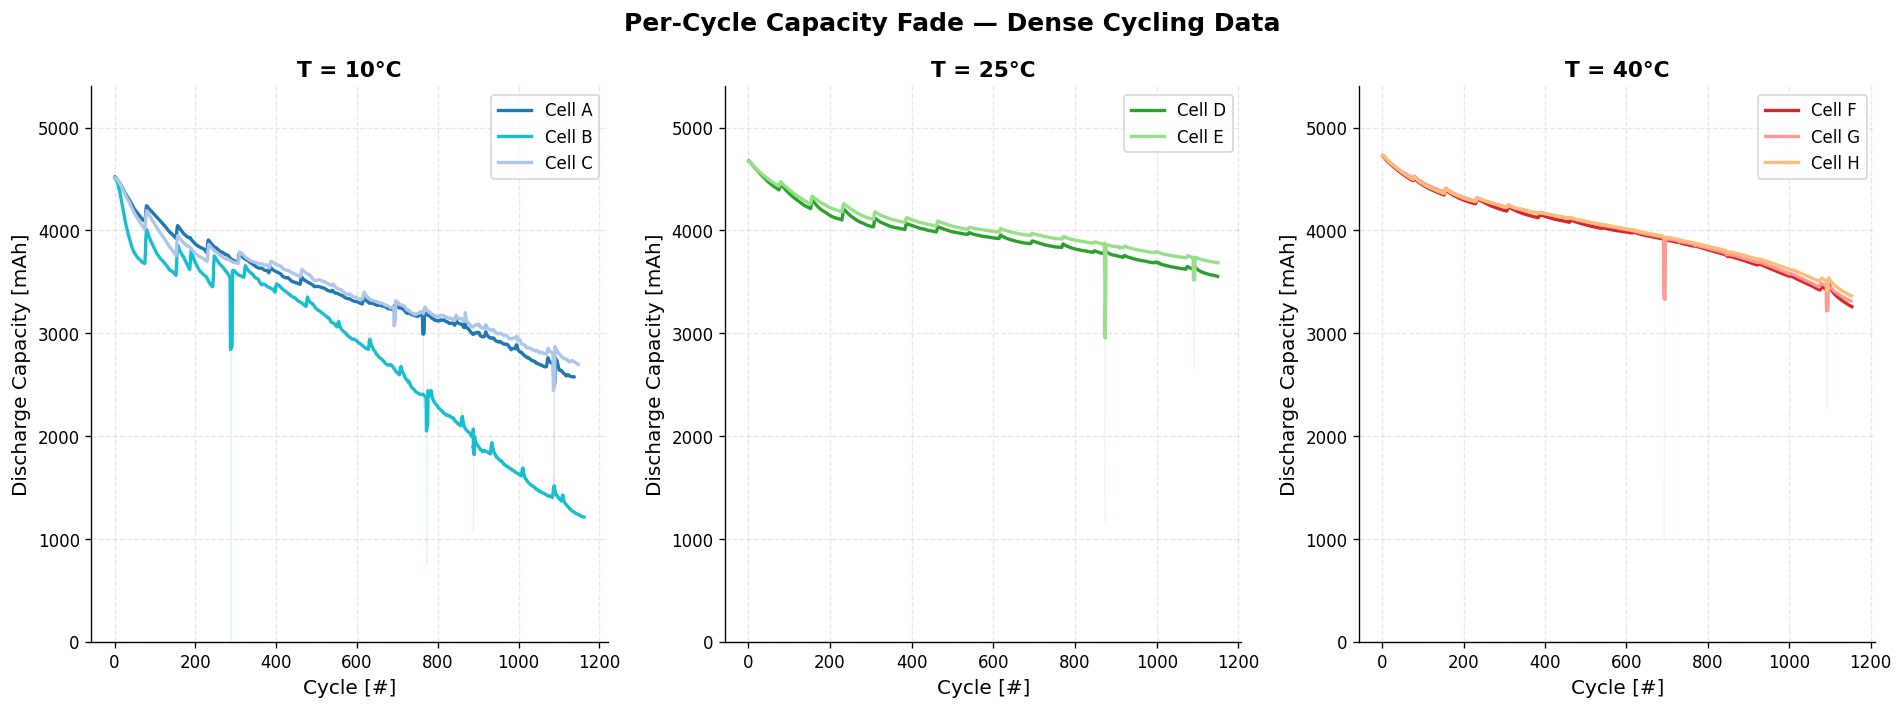

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Per-Cycle Capacity Fade — Dense Cycling Data', fontsize=15, fontweight='bold')

groups = {10: [], 25: [], 40: []}
for c, df in cycles.items(): groups[CELL_CONFIG[c]['temp']].append((c, df))

for ax, (temp, grp) in zip(axes, groups.items()):
    ax.set_title(f'T = {temp}°C', fontweight='bold')
    for c, df in grp:
        x  = df['Cycle'].values
        y  = df['Discharge Capacity [A h]'].values * 1000
        ys = pd.Series(y).rolling(5, min_periods=1, center=True).mean().values
        ax.plot(x, y,  color=cl(c), alpha=0.15, lw=0.5)
        ax.plot(x, ys, color=cl(c), lw=2.0, label=f'Cell {c}')
    ax.set_xlabel('Cycle [#]'); ax.set_ylabel('Discharge Capacity [mAh]')
    ax.set_ylim(0, 5400); ax.legend()

fig.tight_layout()
plt.savefig('Fig05_Cycle_Capacity.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Figure 6 — Coulombic Efficiency Evolution

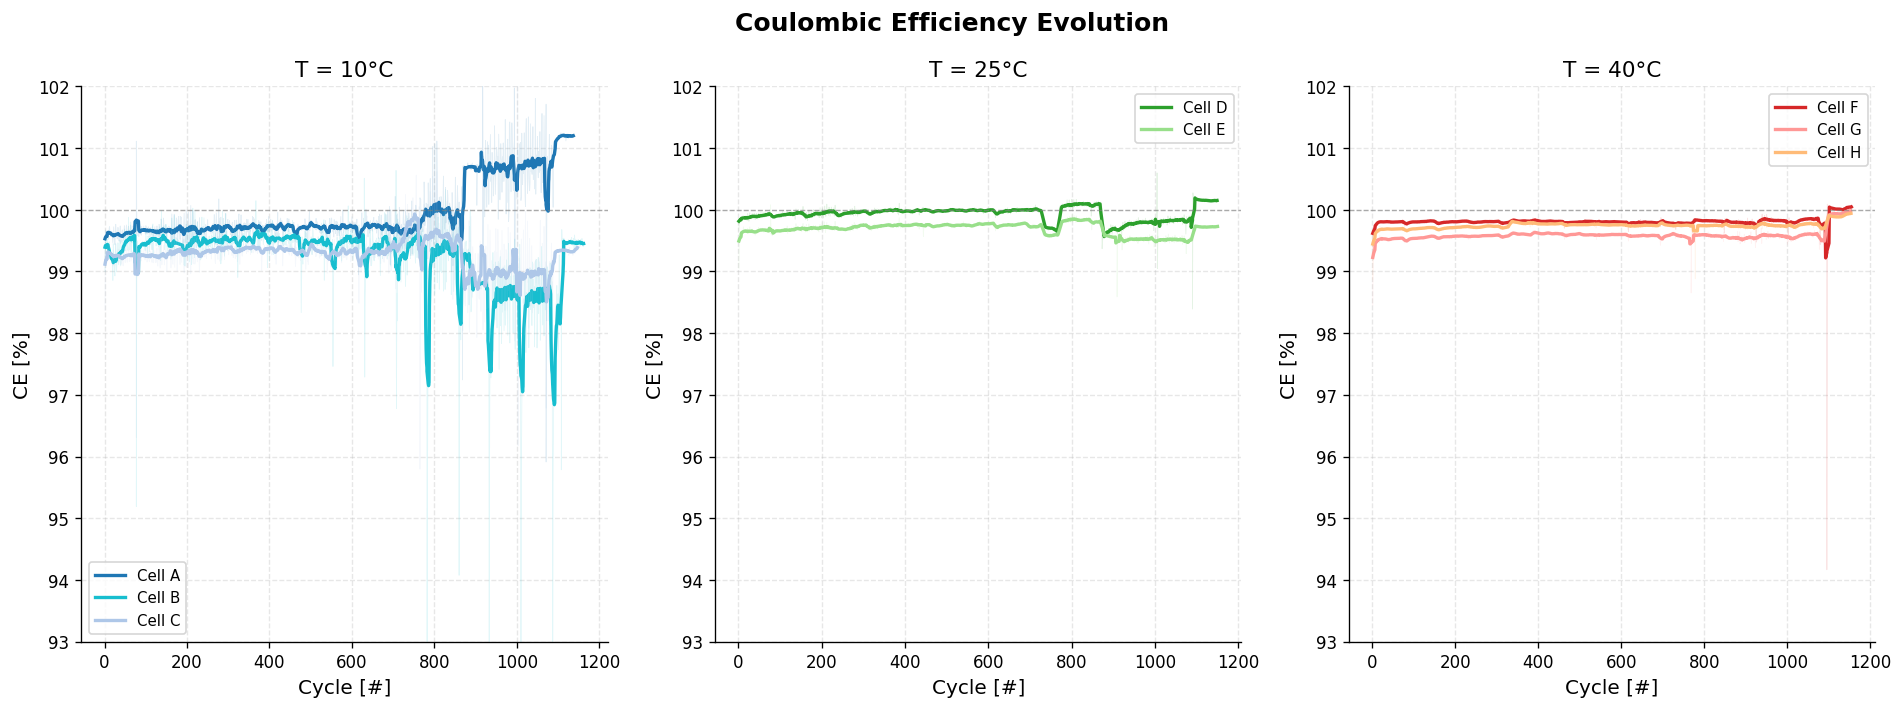

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Coulombic Efficiency Evolution', fontsize=15, fontweight='bold')

groups = {10: [], 25: [], 40: []}
for c, df in cycles.items(): groups[CELL_CONFIG[c]['temp']].append((c, df))

for ax, (temp, grp) in zip(axes, groups.items()):
    ax.set_title(f'T = {temp}°C')
    for c, df in grp:
        ce = 'Charge Efficiency'
        if ce not in df.columns: continue
        dd  = df[(df[ce] > 0.85) & (df[ce] < 1.05)]
        x   = dd['Cycle'].values
        y   = dd[ce].values * 100
        ys  = pd.Series(y).rolling(10, min_periods=1, center=True).mean().values
        ax.plot(x, y,  color=cl(c), alpha=0.12, lw=0.5)
        ax.plot(x, ys, color=cl(c), lw=2.0, label=f'Cell {c}')
    ax.axhline(100, color='gray', ls='--', lw=0.8, alpha=0.6)
    ax.set_xlabel('Cycle [#]'); ax.set_ylabel('CE [%]')
    ax.set_ylim(93, 102); ax.legend(fontsize=9)

fig.tight_layout()
plt.savefig('Fig06_Coulombic_Efficiency.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Figure 7 — Temperature Evolution During Cycling

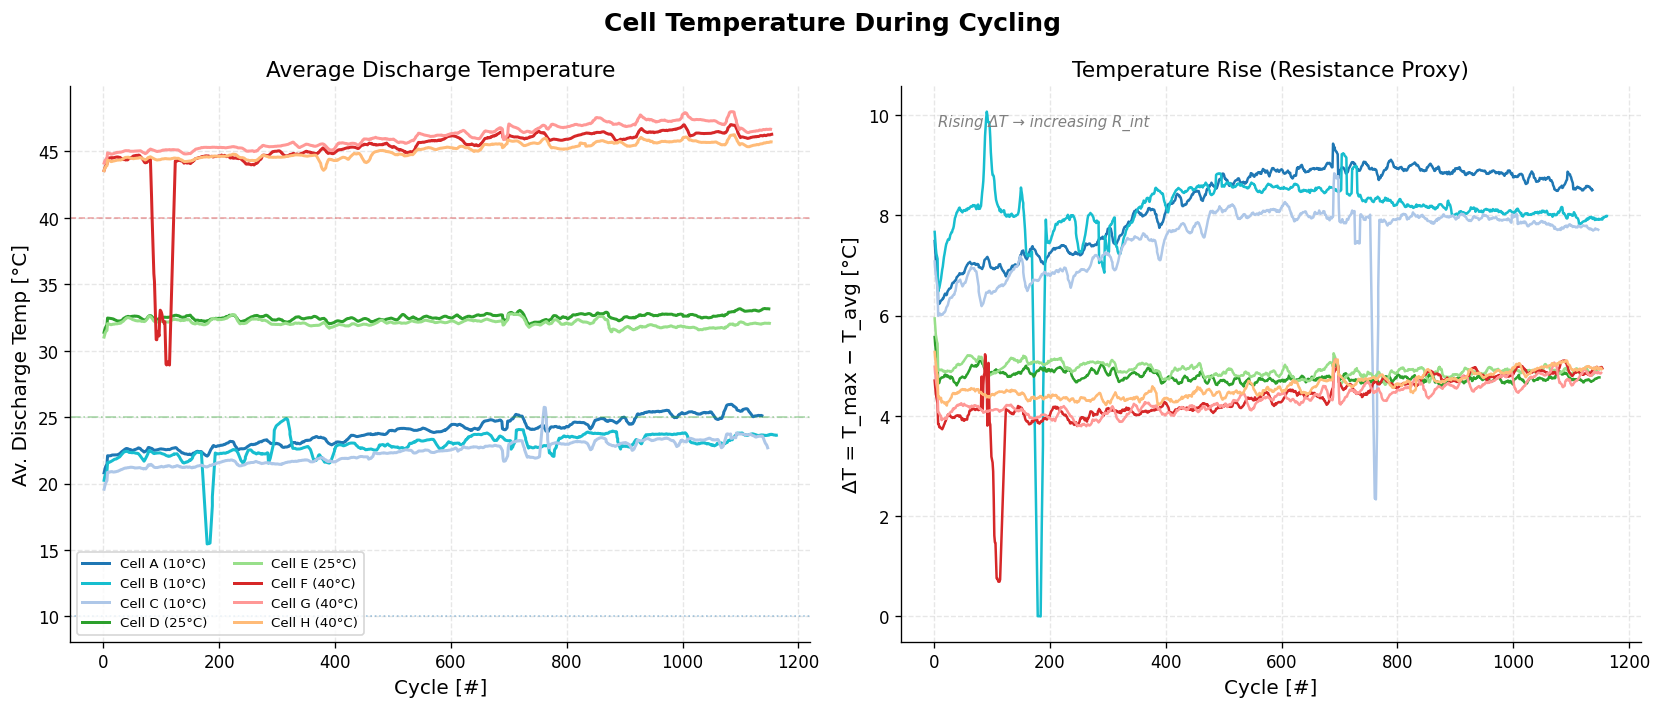

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Cell Temperature During Cycling', fontsize=15, fontweight='bold')

for c, df in cycles.items():
    tc = 'Av. Discharge Temperature [°C]'
    mc = 'Max. Discharge Temperature [°C]'
    if tc not in df.columns: continue
    x  = df['Cycle'].values
    ya = pd.Series(df[tc].values).rolling(10, min_periods=1, center=True).mean().values
    ax1.plot(x, ya, color=cl(c), lw=1.8, label=lb(c))
    if mc in df.columns:
        dT  = df[mc].values - df[tc].values
        dTs = pd.Series(dT).rolling(10, min_periods=1, center=True).mean().values
        ax2.plot(x, dTs, color=cl(c), lw=1.5, label=lb(c))

for t, ls in [(10, ':'), (25, '-.'), (40, '--')]:
    ax1.axhline(t, color=TEMP_COLORS[t], ls=ls, alpha=0.4, lw=1)

ax1.set_xlabel('Cycle [#]'); ax1.set_ylabel('Av. Discharge Temp [°C]')
ax1.set_title('Average Discharge Temperature'); ax1.legend(ncol=2, fontsize=8)
ax2.set_xlabel('Cycle [#]'); ax2.set_ylabel('ΔT = T_max − T_avg [°C]')
ax2.set_title('Temperature Rise (Resistance Proxy)')
ax2.text(0.05, 0.95, 'Rising ΔT → increasing R_int',
         transform=ax2.transAxes, fontsize=9, va='top', style='italic', color='gray')

fig.tight_layout()
plt.savefig('Fig07_Temperature.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Figure 8 — 0.1C Discharge Voltage Curves

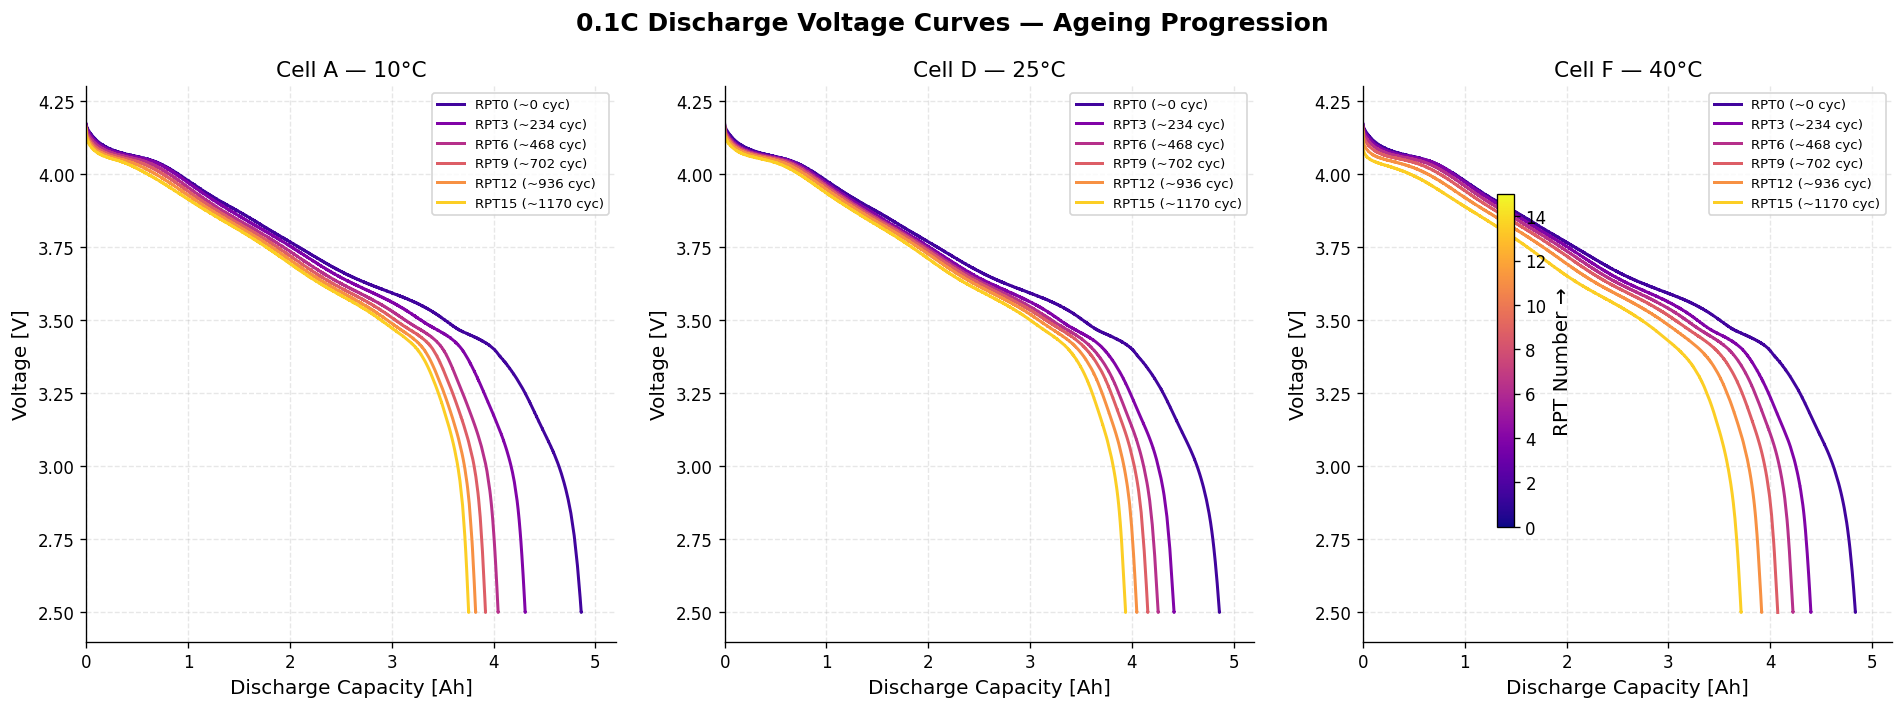

In [12]:
rep  = [('A', 10), ('D', 25), ('F', 40)]
rpts = [0, 3, 6, 9, 12, 15]
clrs = rpt_colors(16)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('0.1C Discharge Voltage Curves — Ageing Progression',
             fontsize=15, fontweight='bold')

for ax, (c, temp) in zip(axes, rep):
    ax.set_title(f'Cell {c} — {temp}°C')
    loaded = 0
    for rpt in rpts:
        df = load_discharge(c, rpt)
        if df is None: continue
        ax.plot(df['Charge (mA.h)'].values/1000, df['Voltage (V)'].values,
                color=clrs[rpt], lw=1.8, label=f'RPT{rpt} (~{rpt*78} cyc)')
        loaded += 1
    ax.set_xlabel('Discharge Capacity [Ah]'); ax.set_ylabel('Voltage [V]')
    ax.set_xlim(0, 5.2); ax.set_ylim(2.4, 4.3)
    if loaded:
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, 'Files not found\nCheck DATA_ROOT path',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=9, color='gray', style='italic')

sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(0, 15))
sm.set_array([])
fig.colorbar(sm, ax=axes, shrink=0.6, pad=0.02, label='RPT Number →')
fig.tight_layout()
plt.savefig('Fig08_Voltage_Curves_01C.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Figure 9 — Incremental Capacity Analysis (dQ/dV)

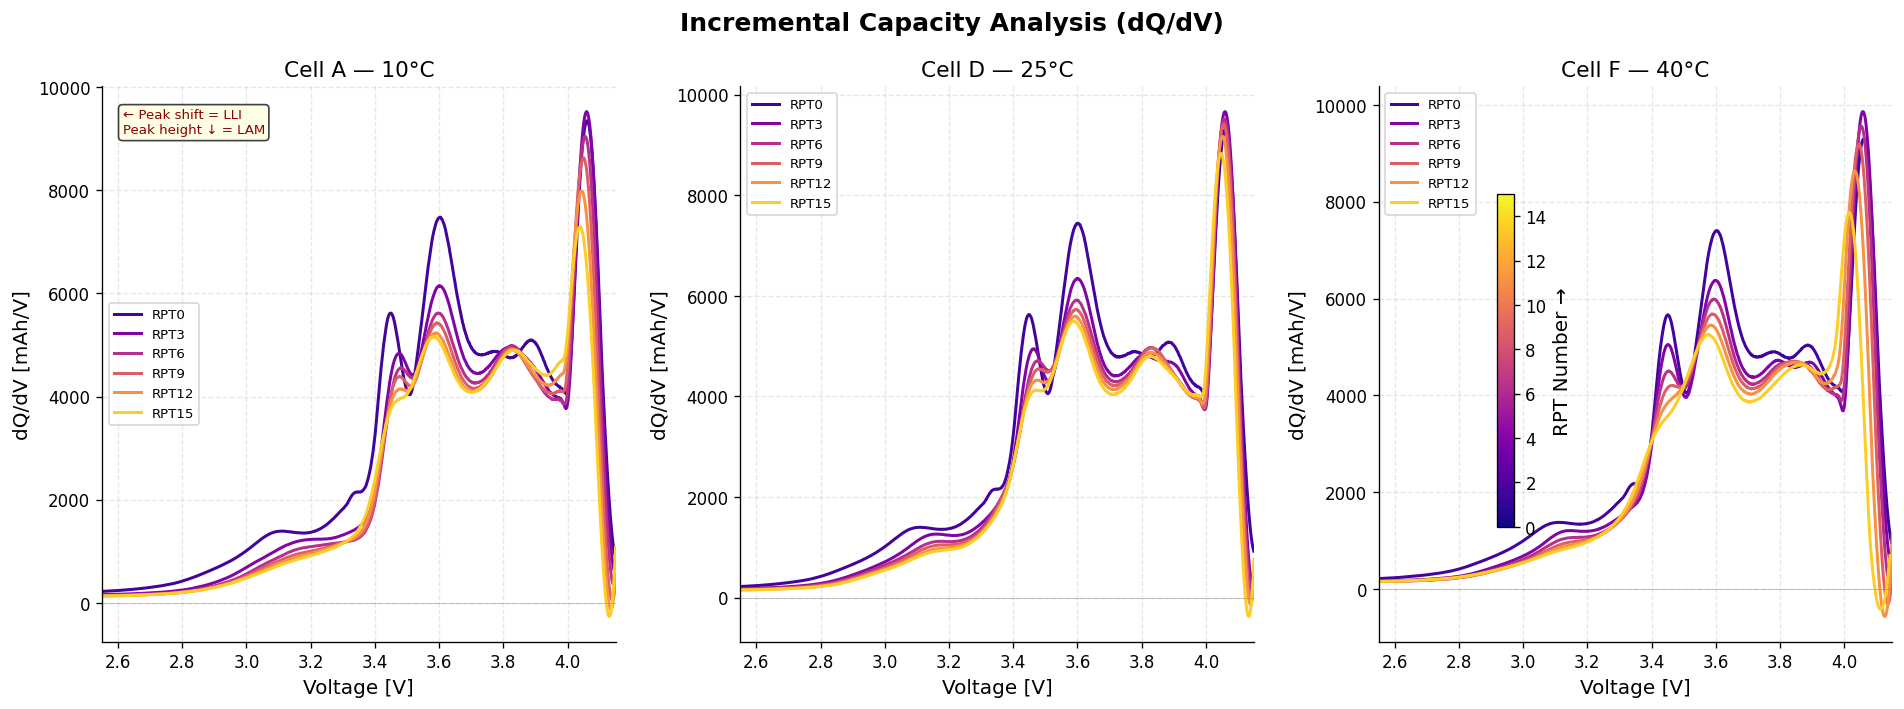

In [13]:
# ── Fixed ica() function ───────────────────────────────────────────────
def ica(df, n=2000, w=151, poly=3):
    if df is None or len(df) < 200:
        return None, None
    
    V = df['Voltage (V)'].values
    Q = df['Charge (mA.h)'].values

    # Sort ASCENDING — interp1d requires strictly increasing x
    idx = np.argsort(V)
    V, Q = V[idx], Q[idx]

    # Remove duplicate voltage values — cubic interp fails on duplicates
    _, unique_idx = np.unique(V, return_index=True)
    V, Q = V[unique_idx], Q[unique_idx]

    # Safety check after deduplication
    if len(V) < 200:
        return None, None

    # Uniform voltage grid
    Vu = np.linspace(V.min(), V.max(), n)

    # Interpolate Q onto uniform grid
    try:
        Qu = interp1d(V, Q, kind='cubic', bounds_error=False,
                      fill_value='extrapolate')(Vu)
    except Exception:
        return None, None

    # If interpolation produced NaNs, abort
    if np.any(np.isnan(Qu)):
        return None, None

    # Compute dQ/dV
    dQdV = np.gradient(Qu, Vu)

    # Smooth the noisy derivative
    if len(dQdV) > w:
        dQdV = savgol_filter(dQdV, w, poly)

    return Vu, -dQdV


# ── Figure 9 — Incremental Capacity Analysis (dQ/dV) ──────────────────
rep  = [('A', 10), ('D', 25), ('F', 40)]
rpts = [0, 3, 6, 9, 12, 15]
clrs = rpt_colors(16)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Incremental Capacity Analysis (dQ/dV)', fontsize=15, fontweight='bold')

for ax, (c, temp) in zip(axes, rep):
    ax.set_title(f'Cell {c} — {temp}°C')
    loaded = 0

    for rpt in rpts:
        df = load_discharge(c, rpt)
        Vu, dQdV = ica(df)
        if Vu is None:
            continue
        mask = (Vu >= 2.55) & (Vu <= 4.15)
        ax.plot(Vu[mask], dQdV[mask], color=clrs[rpt], lw=1.8, label=f'RPT{rpt}')
        loaded += 1

    ax.axhline(0, color='gray', lw=0.5, alpha=0.5)
    ax.set_xlabel('Voltage [V]')
    ax.set_ylabel('dQ/dV [mAh/V]')
    ax.set_xlim(2.55, 4.15)

    if loaded:
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, 'Files not found',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=9, color='gray', style='italic')

axes[0].text(0.04, 0.96, '← Peak shift = LLI\nPeak height ↓ = LAM',
             transform=axes[0].transAxes, fontsize=8, va='top', color='darkred',
             bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.75))

sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(0, 15))
sm.set_array([])
fig.colorbar(sm, ax=axes, shrink=0.6, pad=0.02, label='RPT Number →')

fig.tight_layout()
plt.savefig('Fig09_ICA_dQdV.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

Saved: Fig09_ICA_CellA_10degC.png


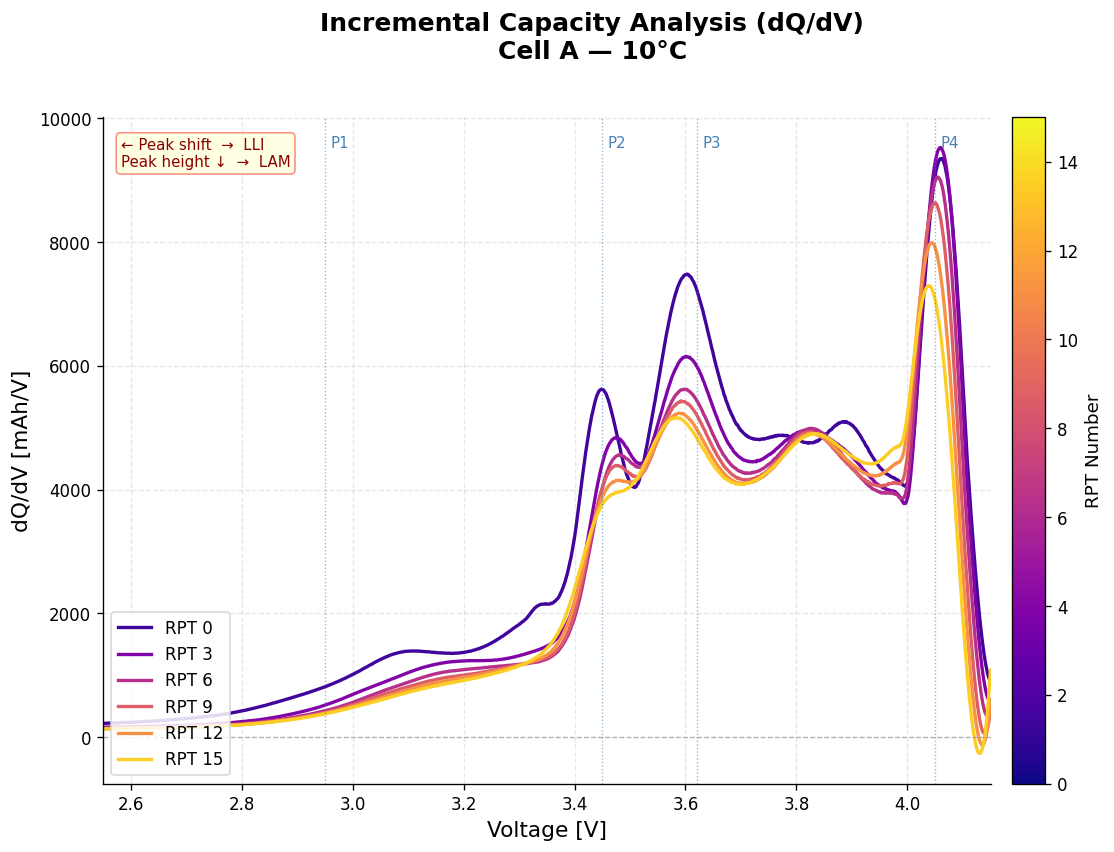

Saved: Fig09_ICA_CellD_25degC.png


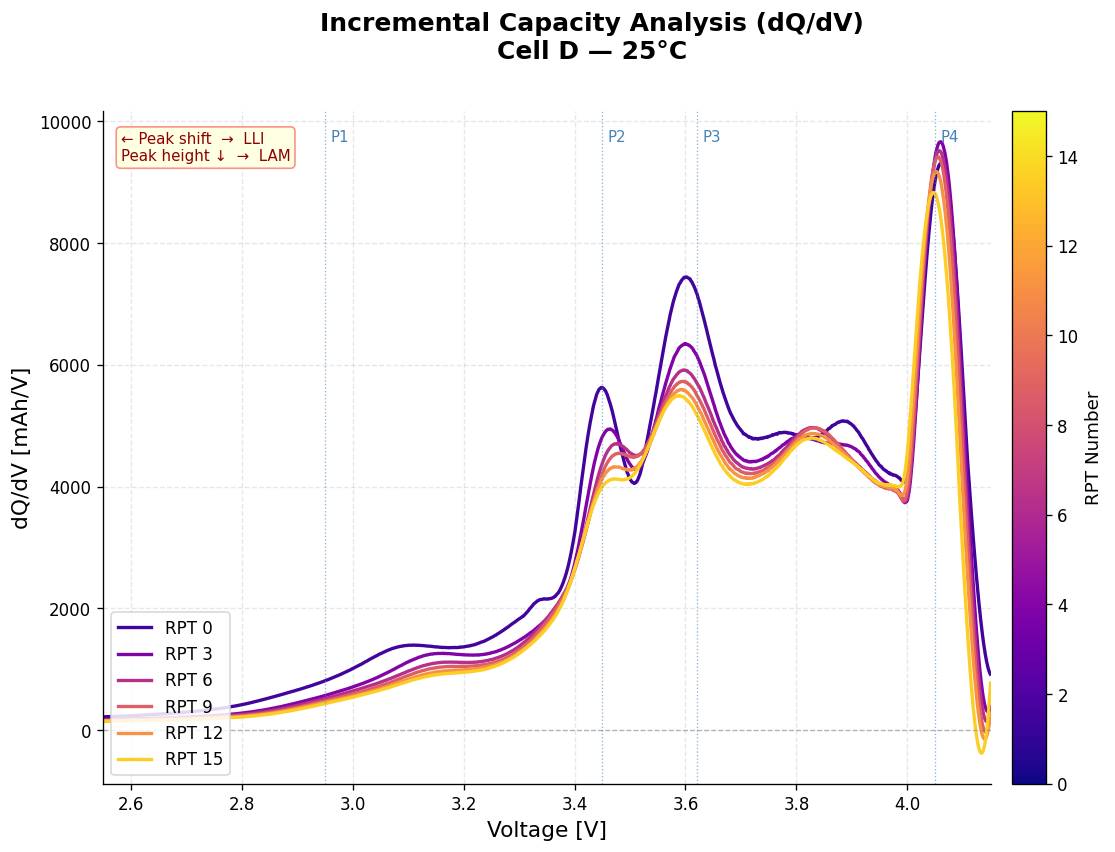

Saved: Fig09_ICA_CellF_40degC.png


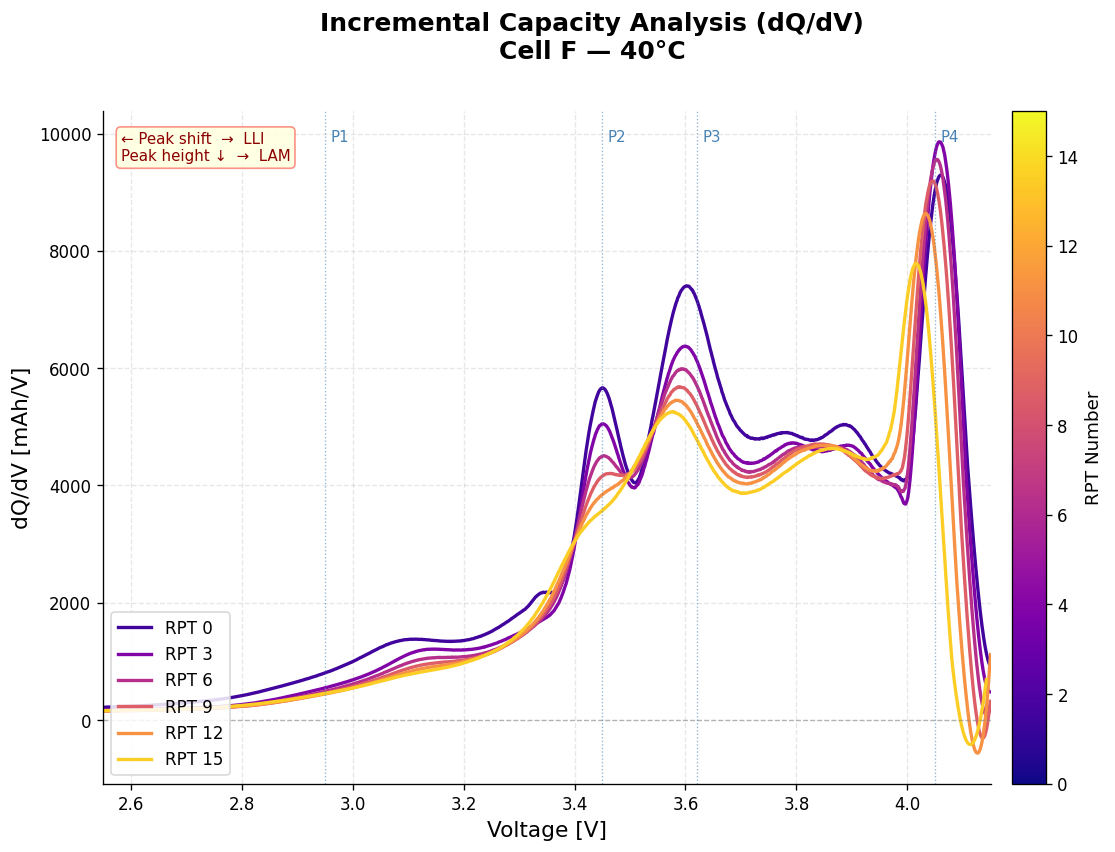

In [14]:
def ica(df, n=2000, w=151, poly=3):
    if df is None or len(df) < 200:
        return None, None
    V = df['Voltage (V)'].values
    Q = df['Charge (mA.h)'].values
    idx = np.argsort(V)
    V, Q = V[idx], Q[idx]
    _, unique_idx = np.unique(V, return_index=True)
    V, Q = V[unique_idx], Q[unique_idx]
    if len(V) < 200:
        return None, None
    Vu = np.linspace(V.min(), V.max(), n)
    try:
        Qu = interp1d(V, Q, kind='cubic', bounds_error=False,
                      fill_value='extrapolate')(Vu)
    except Exception:
        return None, None
    if np.any(np.isnan(Qu)):
        return None, None
    dQdV = np.gradient(Qu, Vu)
    if len(dQdV) > w:
        dQdV = savgol_filter(dQdV, w, poly)
    return Vu, -dQdV   # negated for discharge convention


# ── Separate figure for each cell ─────────────────────────────────────
rep  = [('A', 10), ('D', 25), ('F', 40)]
rpts = [0, 3, 6, 9, 12, 15]
clrs = rpt_colors(16)

for (c, temp) in rep:

    fig, ax = plt.subplots(figsize=(10, 7))

    fig.suptitle(f'Incremental Capacity Analysis (dQ/dV)\nCell {c} — {temp}°C',
                 fontsize=15, fontweight='bold', y=1.01)

    loaded = 0
    for rpt in rpts:
        df = load_discharge(c, rpt)
        Vu, dQdV = ica(df)
        if Vu is None:
            continue
        mask = (Vu >= 2.55) & (Vu <= 4.15)
        ax.plot(Vu[mask], dQdV[mask],
                color=clrs[rpt], lw=2.0, label=f'RPT {rpt}')
        loaded += 1

    ax.axhline(0, color='gray', lw=0.8, alpha=0.5, ls='--')

    ax.set_xlabel('Voltage [V]', fontsize=13)
    ax.set_ylabel('dQ/dV [mAh/V]',  fontsize=13)
    ax.set_xlim(2.55, 4.15)

    # ── Peak labels ───────────────────────────────────────────────────
    for xpos, label in [(2.95, 'P1'), (3.45, 'P2'), (3.62, 'P3'), (4.05, 'P4')]:
        ax.axvline(xpos, color='steelblue', lw=0.8, ls=':', alpha=0.6)
        ax.text(xpos + 0.01, ax.get_ylim()[1] * 0.97 if loaded else 100,
                label, fontsize=9, color='steelblue', va='top')

    # ── Annotation box ────────────────────────────────────────────────
    ax.text(0.02, 0.97,
            '← Peak shift  →  LLI\nPeak height ↓  →  LAM',
            transform=ax.transAxes, fontsize=9, va='top', color='darkred',
            bbox=dict(boxstyle='round', fc='lightyellow', ec='salmon', alpha=0.85))

    # ── Colorbar ──────────────────────────────────────────────────────
    sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(0, 15))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label('RPT Number', fontsize=11)

    # ── Legend ────────────────────────────────────────────────────────
    if loaded:
        ax.legend(fontsize=10, loc='lower left',
                  framealpha=0.85, edgecolor='lightgray')
    else:
        ax.text(0.5, 0.5, 'Files not found',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=11, color='gray', style='italic')

    fig.tight_layout()
    fname = f'Fig09_ICA_Cell{c}_{temp}degC.png'
    plt.savefig(fname, dpi=180, bbox_inches='tight', facecolor='white')
    print(f'Saved: {fname}')
    plt.show()

## Figure 10 — Differential Voltage Analysis (dV/dQ)

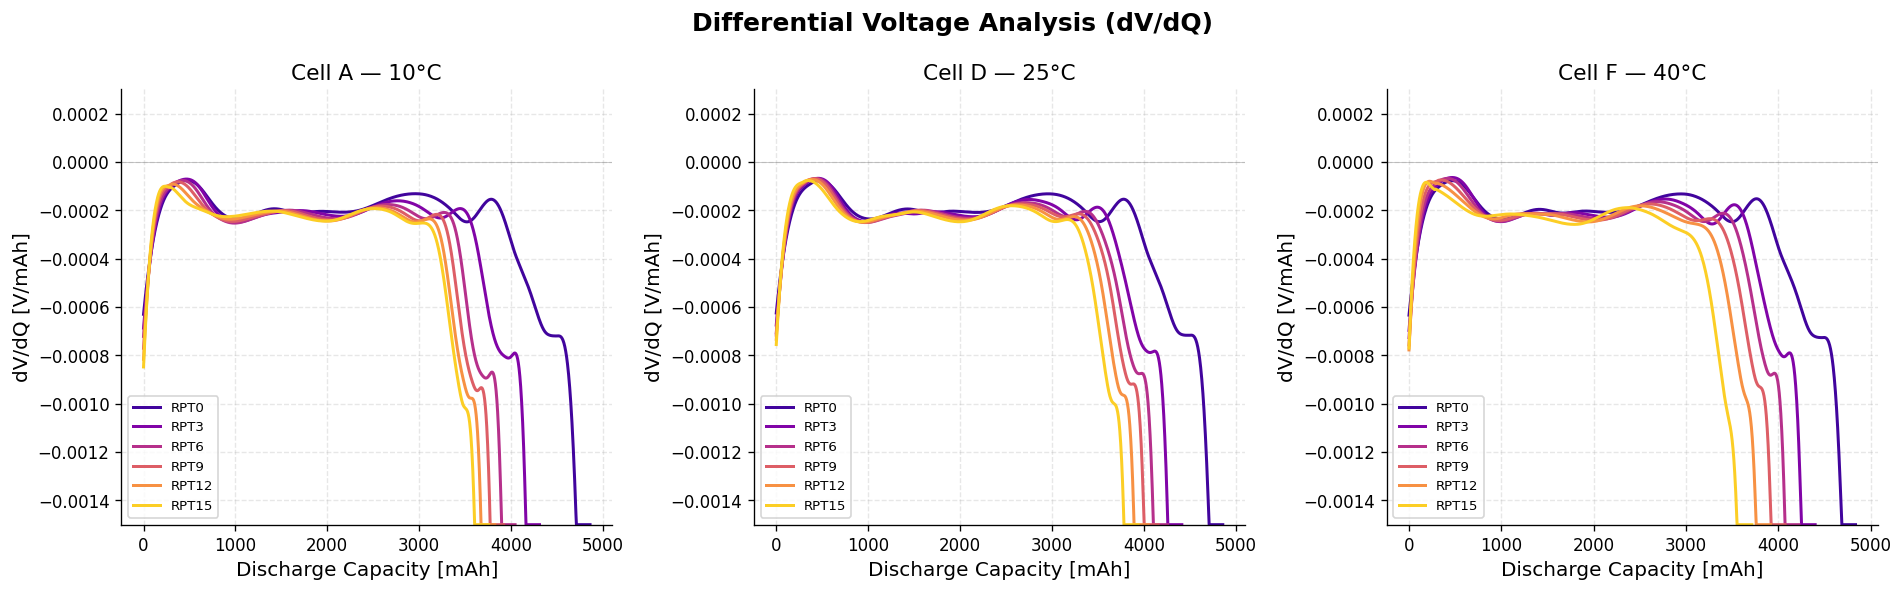

In [15]:
rep  = [('A', 10), ('D', 25), ('F', 40)]
rpts = [0, 3, 6, 9, 12, 15]
clrs = rpt_colors(16)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Differential Voltage Analysis (dV/dQ)', fontsize=15, fontweight='bold')
for ax, (c, temp) in zip(axes, rep):
    ax.set_title(f'Cell {c} — {temp}°C')
    loaded = 0
    for rpt in rpts:
        df = load_discharge(c, rpt)
        Qn, dVdQ = dva(df)
        if Qn is None: continue
        ax.plot(Qn, np.clip(dVdQ, -0.0015, 0.0005), color=clrs[rpt], lw=1.8,
                label=f'RPT{rpt}')
        loaded += 1
    ax.axhline(0, color='gray', lw=0.5, alpha=0.5)
    ax.set_ylim(-0.0015, 0.0003)
    ax.set_xlabel('Discharge Capacity [mAh]')
    ax.set_ylabel('dV/dQ [V/mAh]')
    if loaded:
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, 'Files not found',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=9, color='gray', style='italic')

sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(0, 15))
sm.set_array([])

fig.tight_layout()
plt.savefig('Fig10_DVA_dVdQ.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Figure 11 — Voltage at Fixed SOC Levels

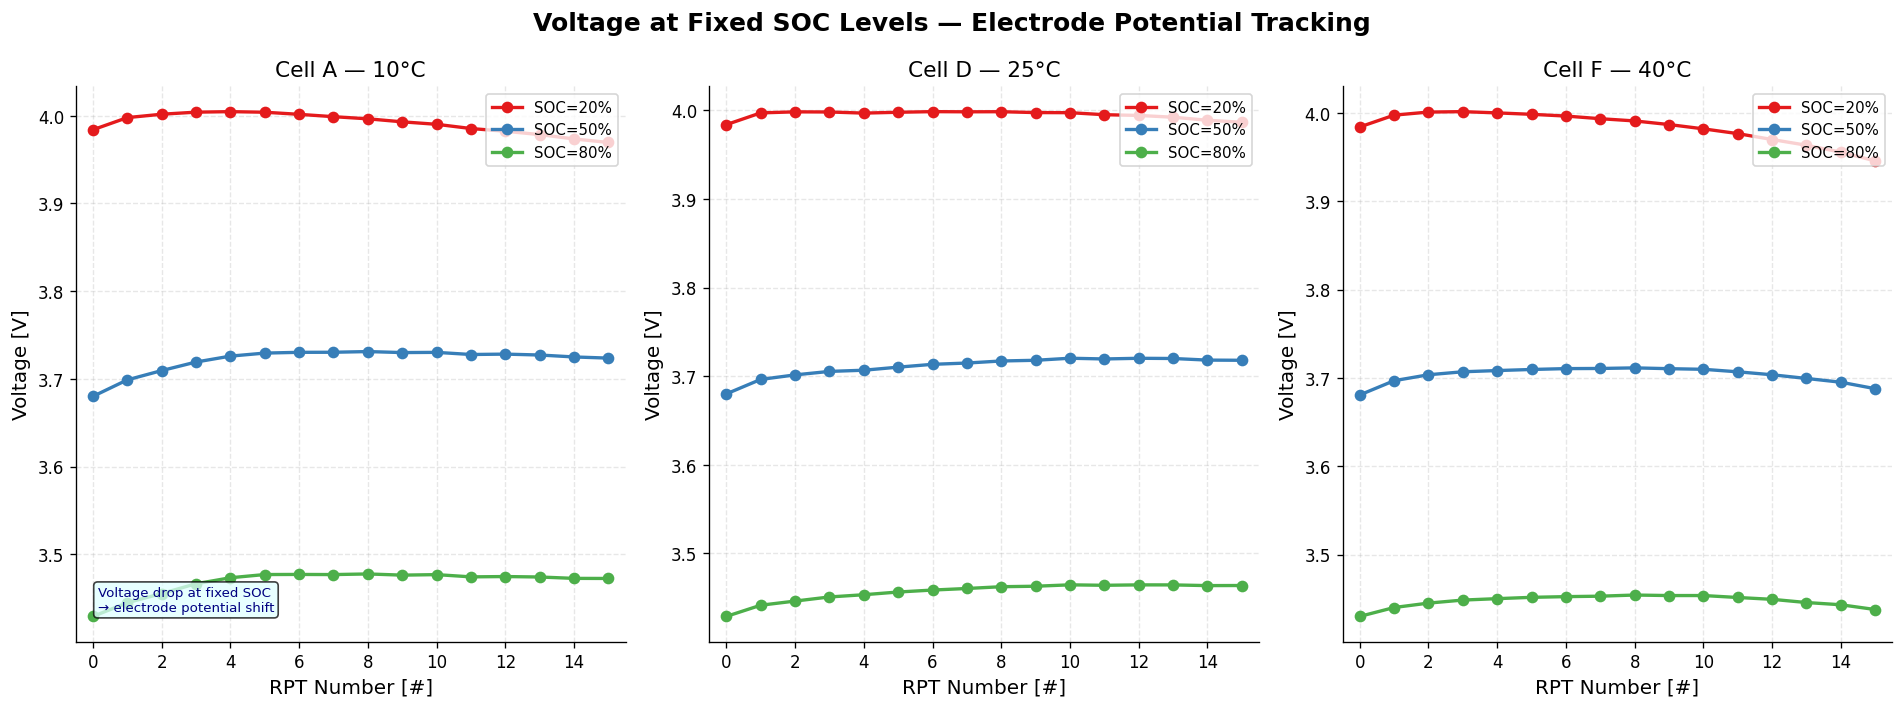

In [16]:
rep  = [('A', 10), ('D', 25), ('F', 40)]
socs  = [0.2, 0.5, 0.8]
scols = ['#e41a1c', '#377eb8', '#4daf4a']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Voltage at Fixed SOC Levels — Electrode Potential Tracking',
             fontsize=15, fontweight='bold')

for ax, (c, temp) in zip(axes, rep):
    ax.set_title(f'Cell {c} — {temp}°C')
    rpts_ok = []
    vdata = {s: [] for s in socs}
    for rpt in range(16):
        df = load_discharge(c, rpt)
        if df is None: continue
        vm = v_at_soc(df, socs)
        if not vm: continue
        rpts_ok.append(rpt)
        for s in socs:
            vdata[s].append(vm.get(s, np.nan))
    if rpts_ok:
        for s, sc in zip(socs, scols):
            ax.plot(rpts_ok, vdata[s], color=sc, marker='o',
                    lw=2.0, ms=6, label=f'SOC={int(s*100)}%')
    ax.set_xlabel('RPT Number [#]'); ax.set_ylabel('Voltage [V]')
    ax.legend(fontsize=9); ax.set_xlim(-0.5, 15.5)
    if not rpts_ok:
        ax.text(0.5, 0.5, 'Files not found',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=9, color='gray', style='italic')

axes[0].text(0.04, 0.05,
             'Voltage drop at fixed SOC\n→ electrode potential shift',
             transform=axes[0].transAxes, fontsize=8, va='bottom', color='navy',
             bbox=dict(boxstyle='round', fc='lightcyan', alpha=0.75))

fig.tight_layout()
plt.savefig('Fig11_Voltage_at_SOC.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Figure 12 — Summary Dashboard

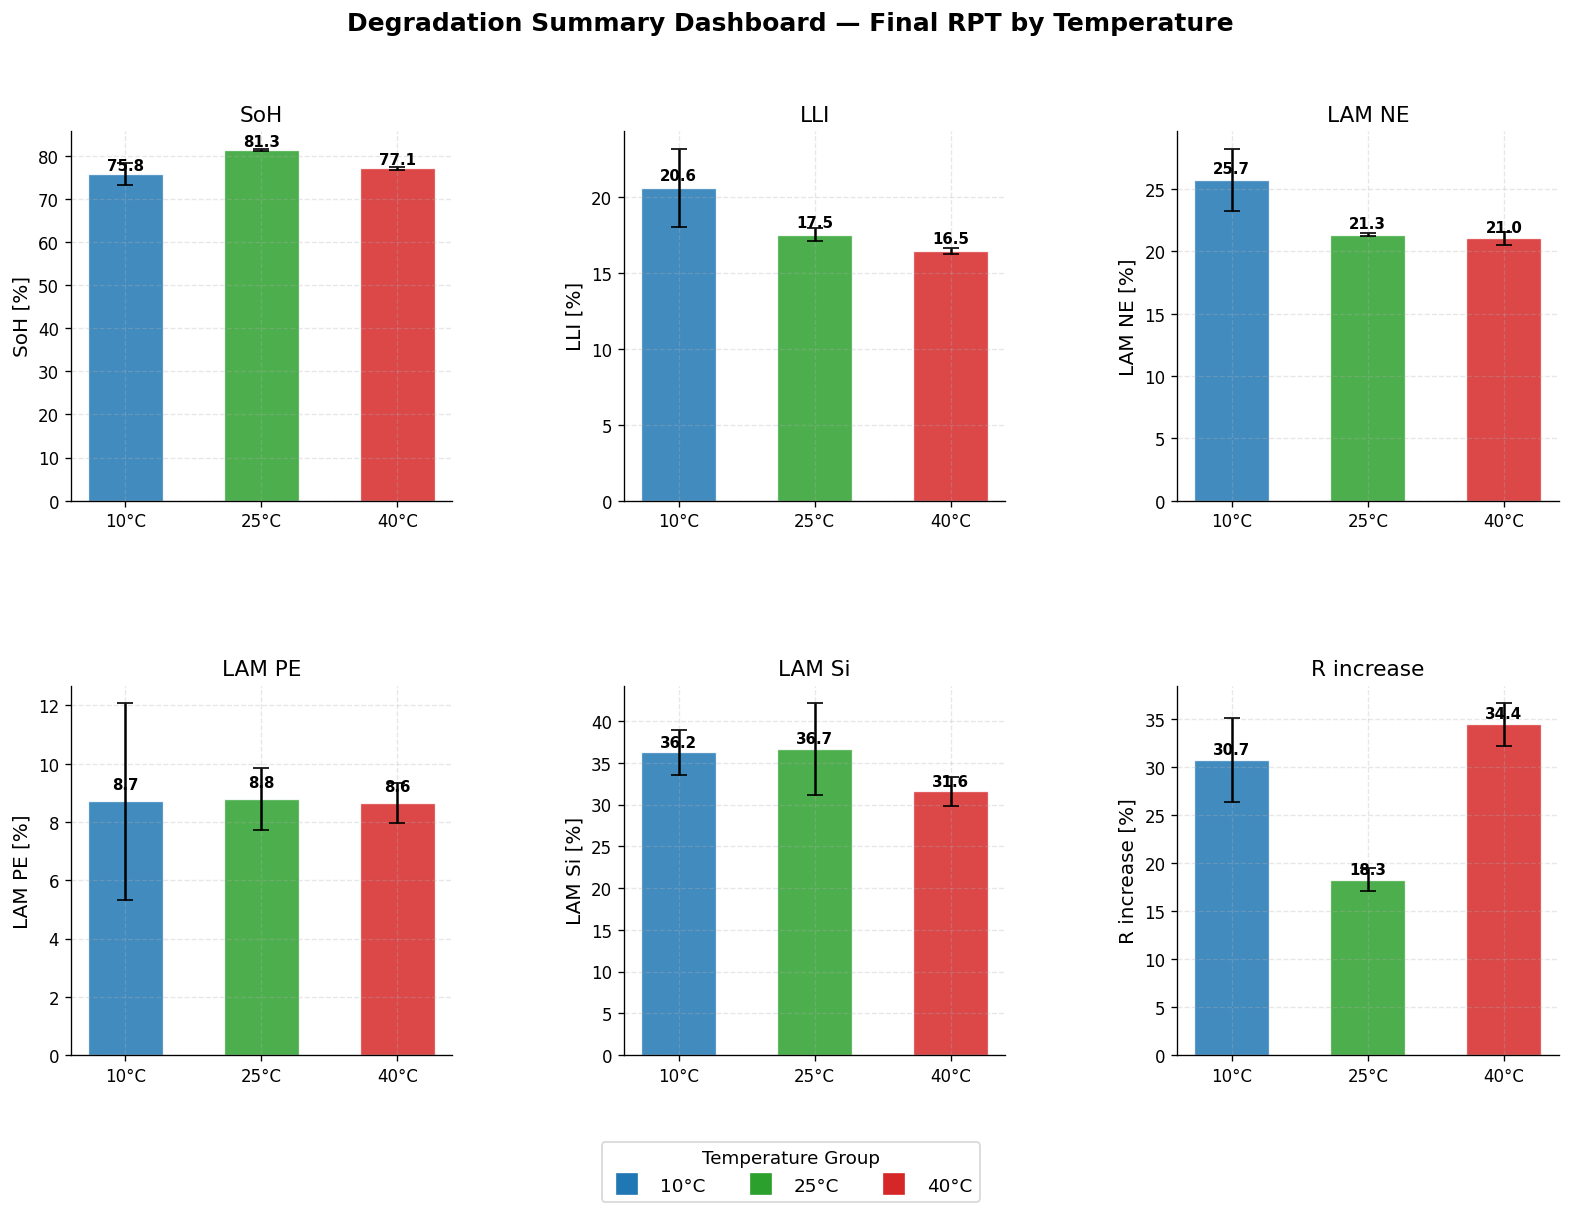

In [17]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Degradation Summary Dashboard — Final RPT by Temperature',
             fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.45)

metrics = [
    ('SoH [%]',        lambda d: d['SoH'].iloc[-1]*100),
    ('LLI [%]',        lambda d: d['LLI'].iloc[-1]*100),
    ('LAM NE [%]',     lambda d: d['LAM NE_tot'].iloc[-1]*100),
    ('LAM PE [%]',     lambda d: d['LAM PE'].iloc[-1]*100),
    ('LAM Si [%]',     lambda d: d['LAM NE_Si'].iloc[-1]*100),
    ('R increase [%]', lambda d: (d['0.1s Resistance [Ohms]'].dropna().iloc[-1] /
                                   d['0.1s Resistance [Ohms]'].dropna().iloc[0] - 1)*100
                                   if len(d['0.1s Resistance [Ohms]'].dropna()) > 1
                                   else np.nan),
]
temps = [10, 25, 40]
x     = np.arange(len(temps))

for idx, (ylabel, fn) in enumerate(metrics):
    ax = fig.add_subplot(gs[idx//3, idx%3])
    cell_vals = {t: [] for t in temps}
    for c, df in summaries.items():
        try:
            v = fn(df)
            if not np.isnan(v):
                cell_vals[CELL_CONFIG[c]['temp']].append(v)
        except Exception:
            pass
    means = [np.mean(cell_vals[t]) if cell_vals[t] else np.nan for t in temps]
    stds  = [np.std(cell_vals[t])  if len(cell_vals[t]) > 1 else 0 for t in temps]

    bars = ax.bar(x, means, width=0.55,
                  color=[TEMP_COLORS[t] for t in temps],
                  alpha=0.85, edgecolor='white', lw=0.8)
    ax.errorbar(x, means, yerr=stds, fmt='none', color='black', capsize=5, lw=1.5)
    for bar, m in zip(bars, means):
        if not np.isnan(m):
            ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.3,
                    f'{m:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{t}°C' for t in temps])
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel.split(' [')[0])

leg = [Line2D([0],[0], color=TEMP_COLORS[t], lw=0, marker='s',
              markersize=12, label=f'{t}°C') for t in temps]
fig.legend(handles=leg, loc='lower center', ncol=3, fontsize=11,
           title='Temperature Group', bbox_to_anchor=(0.5, -0.02))

plt.savefig('Fig12_Summary_Dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 💾 Export All Figures to a Single PDF

In [18]:
from matplotlib.backends.backend_pdf import PdfPages
import glob

out_pdf = 'kirkaldy_degradation_analysis.pdf'
png_files = sorted(glob.glob('Fig*.png'))

if png_files:
    from PIL import Image as PILImage
    with PdfPages(out_pdf) as pdf:
        for png in png_files:
            img = PILImage.open(png)
            fig, ax = plt.subplots(figsize=(img.width/150, img.height/150))
            ax.imshow(img)
            ax.axis('off')
            pdf.savefig(fig, bbox_inches='tight', facecolor='white')
            plt.close(fig)
        d = pdf.infodict()
        d['Title']   = 'Kirkaldy LG M50T — Degradation Analysis'
        d['Subject'] = 'Battery Aging — PINN MTP Project'
    print(f'✅ PDF saved: {out_pdf}')
    print(f'   Includes {len(png_files)} figures:')
    for f in png_files: print(f'   • {f}')
else:
    print('⚠️  No Fig*.png files found — run the figure cells above first.')

✅ PDF saved: kirkaldy_degradation_analysis.pdf
   Includes 15 figures:
   • Fig01_SOH_Fade.png
   • Fig02_Degradation_Modes.png
   • Fig03_Electrode_Capacity.png
   • Fig04_Resistance.png
   • Fig05_Cycle_Capacity.png
   • Fig06_Coulombic_Efficiency.png
   • Fig07_Temperature.png
   • Fig08_Voltage_Curves_01C.png
   • Fig09_ICA_CellA_10degC.png
   • Fig09_ICA_CellD_25degC.png
   • Fig09_ICA_CellF_40degC.png
   • Fig09_ICA_dQdV.png
   • Fig10_DVA_dVdQ.png
   • Fig11_Voltage_at_SOC.png
   • Fig12_Summary_Dashboard.png
